# LLM Inner Structure Analysis with Mesh grid
## Process Overview
1. Load any complex LLM (like LLAMA) and analysis it's architecture
2. Extract the final layer in LLM which performs the softmax. (MLP or Fully connected NN)
3. Now sample the input vectors, similar to p a mesh gird.
  - Since it's difficult to sample 100 points in each of 500 direction, let's fix all the points to some value except 2 or 3. Now sample points from these direction by dividing the scale into 100 points.
4. Now perform classification to predict the next word for a given input vector.
5. When you plot this in the mesh gird, you might see clusters which corresponds to a token.
Now count the number of these mesh grid point inside each cluster and do the similar statistics.

## Statistics
1. Point counts
  - Save the count in a vector. Rearrange them, and plot the count in y-axis and matrix index in the x-axis.
  - Also plot the log log plot using the count matrix.
  - Fit the log log plot with linear line and get the slope.
2. Cluster counts
  - Find the number of clusters with a given size. Ex. 5 clusters has 3 points in them, 7 clusters have 2 points in them...
  - Save the (number of clusters) count in a vector. Rearrange them, and plot the count in y-axis and matrix index in the x-axis.
  - Also plot the log log plot using the count matrix.
  - Fit the log log plot with linear line and get the slope.


### 1. Data & Model Load

In [1]:
# use wikipedia dataset
import json

filename = "/content/wikipedia_1000_sentences.json"
with open(filename, "r", encoding="utf-8") as f:
  sentences = json.load(f)

print(sentences)

['Anarchism is a political philosophy and movement that is skeptical of all justifications for authority and seeks to abolish the institutions it claims maintain unnecessary coercion and hierarchy, typically including nation-states, and capitalism.', 'Anarchism advocates for the replacement of the state with stateless societies and voluntary free associations.', 'As a historically left-wing movement, this reading of anarchism is placed on the farthest left of the political spectrum, usually described as the libertarian wing of the socialist movement (libertarian socialism).', 'Humans have lived in societies without formal hierarchies long before the establishment of states, realms, or empires.', 'With the rise of organised hierarchical bodies, scepticism toward authority also rose.', 'Although traces of anarchist ideas are found all throughout history, modern anarchism emerged from the Enlightenment.', "During the latter half of the 19th and the first decades of the 20th century, the a

In [9]:
import torch
from transformers import BertTokenizer, BertModel, BertForMaskedLM
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, output_hidden_states=True) # predict next words
model.eval()

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:817: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_hidden_states` is. When `return_dict_in_generate` is not `True`, `output_hidden_states` is ignored.
  warnings.warn(


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

### 2. Extract [CLS] token in the last layer

In [13]:
def get_features(sentence, model, tokenizer, layer_indices=-1):
    inputs = tokenizer(sentence, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    hidden_states = outputs.hidden_states[layer_indices]  # [1, seq_len, hidden_dim]

    last_token_index = -1
    final_layer_emb = hidden_states[0, last_token_index, :].cpu().numpy()

    return final_layer_emb

In [14]:
import numpy as np

batch_size = 32
num_batches = len(sentences) // batch_size + (len(sentences) % batch_size != 0)

final_embeddings = []

for i in range(num_batches):
    batch = sentences[i * batch_size: (i + 1) * batch_size]

    for sent in batch:
      emb = get_features(sent, model, tokenizer)
      final_embeddings.append(emb)

final_embeddings = np.array(final_embeddings)

print("Final embedding shape:", final_embeddings.shape)

Final embedding shape: (1000, 768)


### 3. PCA and sampling in Mesh Grid Space

In [19]:
# decomposition and visualization

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. decomposition
pca = PCA(n_components=2) # 2D spaces (100 x 100 grid)
pca_space = pca.fit_transform(final_embeddings)

# 2. Mesh point
x_min, x_max = pca_space[:, 0].min(), pca_space[:,0].max()
y_min, y_max = pca_space[:, 1].min(), pca_space[:,1].max()

x_grid, y_grid = np.meshgrid(np.linspace(x_min, x_max, 100),
                             np.linspace(y_min, y_max, 100))

mesh_points = np.vstack([x_grid.ravel(), y_grid.ravel()]).T

print(mesh_points.shape) # shape: (10000, 2)

(10000, 2)


In [20]:
print("x min, x max:", x_min, x_max)
print("y_min, y_max:", y_min, y_max)

x min, x max: -301.92114 79.174255
y_min, y_max: -48.006897 55.10182


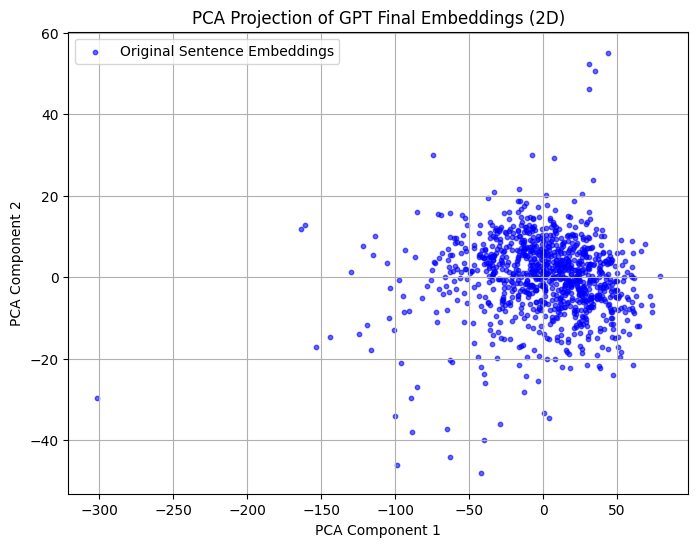

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_space[:, 0], pca_space[:, 1], alpha=0.6, s=10, c='blue', label='Original Sentence Embeddings')
plt.title("PCA Projection of GPT Final Embeddings (2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.legend()
plt.show()

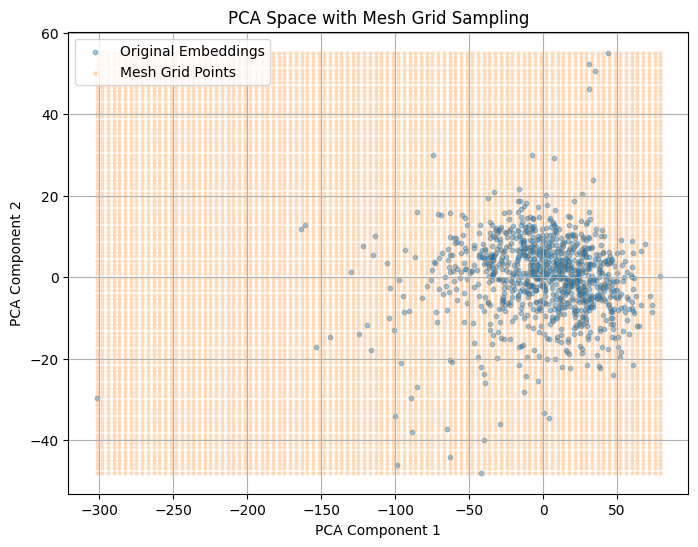

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_space[:, 0], pca_space[:, 1], alpha=0.4, s=10, label='Original Embeddings')
plt.scatter(mesh_points[:, 0], mesh_points[:, 1], alpha=0.2, s=5, label='Mesh Grid Points')
plt.title("PCA Space with Mesh Grid Sampling")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.legend()
plt.show()

### 4. predict the next token

In [27]:
# 2) predict next token
import torch.nn.functional as F

final_tensor = torch.tensor(final_embeddings, dtype=torch.float32) # (10000, hidden_dim)

batch_size = 32
num_batches = (len(final_tensor) + batch_size - 1) // batch_size

predicted_token_ids = []
predicted_tokens = []
max_probs = []

for i in range(num_batches):
    batch = final_tensor[i * batch_size: (i + 1) * batch_size]

    batch = batch.unsqueeze(1) # [batch_size, seq_len=1, hidden_dim]
    with torch.no_grad():
        outputs = model(inputs_embeds =batch)
        logits = outputs.logits # [batch_size, seq_len=1, vocab_size]
        probs = F.softmax(logits[:, -1, :], dim=-1)
        max_prob, pred_ids = torch.max(probs, dim=-1)

        predicted_token_ids.extend(pred_ids.tolist())
        predicted_tokens.extend(tokenizer.convert_ids_to_tokens(pred_ids.tolist(), skip_special_tokens=True))
        max_probs.extend(max_prob.tolist())

In [28]:
# Sanity checks
unique_tokens, counts = np.unique(predicted_tokens, return_counts=True)
top_tokens = sorted(zip(unique_tokens, counts), key=lambda x: x[1], reverse=True)[:10]

print(f"Total points processed: {len(final_tensor)}")
print(f"Number of unique predicted tokens: {len(set(predicted_tokens))}")
print("Top 10 most frequent predicted tokens:")
for token, count in top_tokens:
    print(f"{token}: {count}")
print(f"  Max predicted probability: {max(max_probs):.4f}")
print(f"  Min predicted probability: {min(max_probs):.4f}")
print(f"  Average predicted probability: {np.mean(max_probs):.4f}")

Total points processed: 1000
Number of unique predicted tokens: 3
Top 10 most frequent predicted tokens:
Ċ: 996
.: 3
ĠThe: 1
  Max predicted probability: 0.3048
  Min predicted probability: 0.0789
  Average predicted probability: 0.2102
